# Flood event definition

This notebook defines RP-3 exceedance events for the 4 selected LGAs in Borno state and saves them to a parquet file. All other notebooks that need flood events should load from that file rather than re-implementing the logic.

**Event definition:**
- Floodscan SFED is smoothed with a 3-day rolling average to reduce day-to-day noise
- The RP-3 threshold per LGA is computed from empirical annual maxima during the flood season (June–November, 1998–2025)
- Any day where smoothed SFED ≥ RP-3 threshold is flagged as an exceedance, across the full calendar year
- Consecutive exceedance periods separated by ≤ 7 days are merged into a single event

**Output:** `ds-aa-nga-flooding/processed/floodscan_rp3_events.parquet`

In [ ]:
import ocha_stratus as stratus
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from src.utils import rp_calc

load_dotenv()

PCODES       = ['NG008008', 'NG008015', 'NG008019', 'NG008025']
FLOOD_MONTHS = range(6, 12)   # June–November — used only for threshold computation
ROLLING_DAYS = 3              # rolling average window applied to SFED
THRESHOLD_RP = 3              # return period used as flood threshold
GAP_DAYS     = 14             # merge exceedance periods within this gap

OUTPUT_PATH  = 'ds-aa-nga-flooding/processed/floodscan_rp3_events.parquet'

In [21]:
# Load LGA boundaries and Floodscan SFED
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    'ds-aa-nga-flooding/processed/selected_lgas_borno.parquet'
)
gdf_lga_sel = gdf_lga_sel[gdf_lga_sel['ADM2_PCODE'].isin(PCODES)]

df_floodscan = stratus.load_parquet_from_blob(
    'ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas_borno.parquet'
)
df_floodscan = df_floodscan[df_floodscan['pcode'].isin(PCODES)].copy()
df_floodscan['date'] = pd.to_datetime(df_floodscan['valid_date']).dt.normalize()
df_floodscan = df_floodscan.sort_values(['pcode', 'date'])

# 3-day rolling average to smooth noise
df_floodscan['sfed'] = df_floodscan.groupby('pcode')['mean'].transform(
    lambda x: x.rolling(ROLLING_DAYS, min_periods=1).mean()
)

df_floodscan[['pcode', 'date', 'sfed']].head()

,pcode,date,sfed
95992,NG008008,1998-01-12,0.0
96008,NG008008,1998-01-13,0.0
96323,NG008008,1998-01-14,0.0
96339,NG008008,1998-01-15,0.0
96664,NG008008,1998-01-16,0.0


In [22]:
# Compute RP-3 threshold per LGA from seasonal annual maxima (1998–2025)
df_fs_am = (
    df_floodscan[
        df_floodscan['date'].dt.month.isin(FLOOD_MONTHS) &
        (df_floodscan['date'].dt.year < 2026)
    ]
    .assign(year=lambda d: d['date'].dt.year)
    .groupby(['pcode', 'year'])['sfed'].max()
    .reset_index()
)

df_fs_rp = rp_calc.calculate_groups_rp(
    df_fs_am, by=['pcode'], col_name='sfed', ascending=False
)

sfed_thresh = {}
for pcode in PCODES:
    sub = (
        df_fs_rp[df_fs_rp['pcode'] == pcode]
        .dropna(subset=['sfed', 'sfed_rp'])
        .sort_values('sfed_rp')
    )
    sfed_thresh[pcode] = float(
        np.interp(THRESHOLD_RP, sub['sfed_rp'], sub['sfed'])
        if sub['sfed_rp'].max() >= THRESHOLD_RP
        else sub['sfed'].max()
    )

pd.DataFrame([
    {
        'pcode': p,
        'lga': gdf_lga_sel.loc[gdf_lga_sel['ADM2_PCODE'] == p, 'ADM2_EN'].iloc[0],
        f'rp{THRESHOLD_RP}_threshold': round(sfed_thresh[p], 5),
    }
    for p in PCODES
])

,pcode,lga,rp3_threshold
0,NG008008,Dikwa,0.07054
1,NG008015,Kala/Balge,0.18966
2,NG008019,Mafa,0.06598
3,NG008025,Ngala,0.19364


In [23]:
# Identify exceedance events per LGA
# Exceedance periods separated by <= GAP_DAYS are merged into a single event
events = []
for pcode in PCODES:
    lga    = gdf_lga_sel.loc[gdf_lga_sel['ADM2_PCODE'] == pcode, 'ADM2_EN'].iloc[0]
    thresh = sfed_thresh[pcode]

    df_p = (
        df_floodscan[df_floodscan['pcode'] == pcode][['date', 'sfed']]
        .sort_values('date')
        .reset_index(drop=True)
    )
    above = df_p.loc[df_p['sfed'] >= thresh, 'date'].tolist()

    if not above:
        print(f'No exceedances for {lga}')
        continue

    groups, cur = [], [above[0]]
    for d in above[1:]:
        if (d - cur[-1]).days <= GAP_DAYS:
            cur.append(d)
        else:
            groups.append(cur)
            cur = [d]
    groups.append(cur)

    for g in groups:
        sub      = df_p[(df_p['date'] >= g[0]) & (df_p['date'] <= g[-1])]
        peak_row = sub.loc[sub['sfed'].idxmax()]
        events.append({
            'pcode':        pcode,
            'lga':          lga,
            'sfed_thresh':  thresh,
            'event_start':  g[0],
            'event_end':    g[-1],
            'peak_date':    peak_row['date'],
            'peak_sfed':    float(peak_row['sfed']),
            'sfed_norm':    float(peak_row['sfed']) / thresh,
            'year':         int(peak_row['date'].year),
        })

df_events = (
    pd.DataFrame(events)
    .sort_values(['pcode', 'peak_date'])
    .reset_index(drop=True)
)

print(f'Found {len(df_events)} events across {len(PCODES)} LGAs')
df_events

Found 39 events across 4 LGAs


,pcode,lga,sfed_thresh,event_start,event_end,peak_date,peak_sfed,sfed_norm,year
0,NG008008,Dikwa,0.070541,1998-07-25,1998-08-18,1998-08-10,0.121674,1.724879,1998
1,NG008008,Dikwa,0.070541,1998-09-07,1998-09-13,1998-09-10,0.082274,1.166336,1998
2,NG008008,Dikwa,0.070541,2007-07-29,2007-09-25,2007-08-15,0.119825,1.698670,2007
3,NG008008,Dikwa,0.070541,2009-07-28,2009-07-29,2009-07-28,0.083335,1.181370,2009
4,NG008008,Dikwa,0.070541,2010-07-25,2010-09-18,2010-08-15,0.143514,2.034488,2010
5,NG008008,Dikwa,0.070541,2012-06-28,2012-06-28,2012-06-28,0.083963,1.190277,2012
6,NG008008,Dikwa,0.070541,2012-09-06,2012-09-26,2012-09-22,0.092664,1.313618,2012
7,NG008008,Dikwa,0.070541,2014-07-09,2014-09-12,2014-08-12,0.177331,2.513881,2014
8,NG008008,Dikwa,0.070541,2015-06-24,2015-06-25,2015-06-24,0.077397,1.097195,2015
9,NG008008,Dikwa,0.070541,2018-07-18,2018-07-20,2018-07-19,0.110250,1.562930,2018


In [27]:
# Save to parquet — load this in other notebooks instead of redefining events
stratus.upload_parquet_to_blob(df_events, OUTPUT_PATH)
print(f'Saved {len(df_events)} events to {OUTPUT_PATH}')

# Summary per LGA
df_events.groupby('lga').agg(
    n_events   =(  'peak_date', 'count'),
    first_year =(       'year',   'min'),
    last_year  =(       'year',   'max'),
    mean_sfed_norm=('sfed_norm',  'mean'),
).round(2)

Saved 39 events to ds-aa-nga-flooding/processed/floodscan_rp3_events.parquet


,n_events,first_year,last_year,mean_sfed_norm
lga,,,,
Dikwa,11,1998,2024,1.53
Kala/Balge,9,1998,2024,1.44
Mafa,10,1998,2024,1.67
Ngala,9,1998,2014,1.55


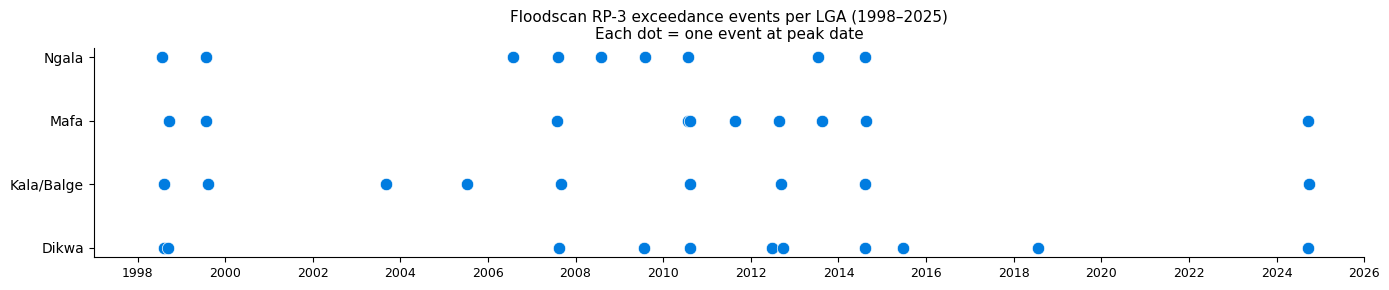

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

lga_order = [
    gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == p, "ADM2_EN"].iloc[0] for p in PCODES
]
y_pos = {lga: i for i, lga in enumerate(lga_order)}

fig, ax = plt.subplots(figsize=(14, 3))

ax.scatter(
    df_events["peak_date"],
    df_events["lga"].map(y_pos),
    color="#007CE0", s=80, edgecolors="white", linewidth=0.5, zorder=3,
)

ax.set_yticks(range(len(lga_order)))
ax.set_yticklabels(lga_order, fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(pd.Timestamp("1997-01-01"), pd.Timestamp("2026-01-01"))
ax.tick_params(axis="x", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title(
    "Floodscan RP-3 exceedance events per LGA (1998–2025)\n"
    "Each dot = one event at peak date",
    fontsize=11,
)

plt.tight_layout()
plt.savefig("figures/flood_event_timeline.png", dpi=300, bbox_inches="tight")
plt.show()